# Updated SAR Analysis: Southern Appalachian Amphibians

Reanalysis of the nested and island species–area models from Stout, Jessee & McMeen (2025) using the [`sars`](https://pypi.org/project/sars/) Python library. The `sars` library fits SAR models via **nonlinear least squares** (NLS) in arithmetic space, rather than the log-linear OLS used in the original publication. NLS minimizes residuals in the species-count scale and assumes additive error, whereas log-linear OLS minimizes residuals in log-space and assumes multiplicative error (Tjørve & Tjørve 2021).

> **Original publication:** Stout, J.B., Jessee, L.D. & McMeen, J.N. (2025). Nested and island models for determining the species-area relationship of southern Appalachian amphibians. *Journal of North American Herpetology* 2025(1):1–7.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import sars
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 120


## Data Loading

Two datasets from the paper's appendices: the nested model (n=7, concentric areas) and island model (n=26, individual sites).


In [2]:
nested_df = pd.read_csv("data/nested.csv")
island_df = pd.read_csv("data/island.csv")

groups = ["AmphibianSpecies", "FrogSpecies", "SalamanderSpecies"]
labels = ["Amphibians", "Frogs", "Salamanders"]

def load_sars(df, col):
    """Write a temp CSV and load via sars.from_csv."""
    tmp = df[["Area", col]].copy()
    tmp.to_csv("/tmp/sars_tmp.csv", index=False)
    return sars.from_csv("/tmp/sars_tmp.csv", area_col="Area", species_col=col)

print(f"Nested: {len(nested_df)} sites, area range {nested_df['Area'].min():.4f} – {nested_df['Area'].max():,.0f} km²")
print(f"Island: {len(island_df)} sites, area range {island_df['Area'].min():.4f} – {island_df['Area'].max():,.0f} km²")

display(nested_df)
display(island_df)


Nested: 7 sites, area range 0.0018 – 178,758 km²
Island: 26 sites, area range 0.0081 – 2,114 km²


,Locality,Area,AmphibianSpecies,FrogSpecies,SalamanderSpecies
0,Area 1,0.0018,10,7,3
1,Area 2,9.3000,22,10,12
2,Area 3,1114.0000,38,13,25
3,Area 4,4137.0000,44,13,31
4,Area 5,37438.0000,69,18,52
5,Area 6,101271.0000,88,20,68
6,Area 7,178758.0000,98,22,76


,Locality,Area,AmphibianSpecies,FrogSpecies,SalamanderSpecies
0,John's Bog (Blue Ridge),0.0081,10,1,9
1,Henderson Bog,0.1010,12,5,7
2,UT Arboretum,1.0100,16,9,7
3,"Sweet's Farm, Highland Co. VA",1.5700,13,5,8
4,Cantonment Area WV,3.7800,17,7,10
5,Briery Mountain WV,4.2300,14,4,10
6,Pringle Tract WV,8.5400,11,4,7
7,Harper's Ferry NHP WV,9.6500,16,6,10
8,New River SP NC,13.4500,18,7,11
9,Elk Knob SP NC,17.9000,17,4,13


## Power-Law Fits (S = cA^z)

### Nested Model


In [3]:
nested_power = {}

for label, col in zip(labels, groups):
    data = load_sars(nested_df, col)
    fit = sars.sar_power(data)
    nested_power[label] = fit
    print(f"{label}:  c = {fit.params['c']:.4f},  z = {fit.params['z']:.4f},  R² = {fit.r_squared:.4f}")
    print(f"          AIC = {fit.aic:.2f},  AICc = {fit.aicc:.2f},  BIC = {fit.bic:.2f}")
    print()


Amphibians:  c = 11.1076,  z = 0.1779,  R² = 0.9826
          AIC = 45.47,  AICc = 53.47,  BIC = 45.31

Frogs:  c = 8.2195,  z = 0.0753,  R² = 0.9281
          AIC = 30.15,  AICc = 38.15,  BIC = 29.99

Salamanders:  c = 5.3315,  z = 0.2192,  R² = 0.9951
          AIC = 34.09,  AICc = 42.09,  BIC = 33.92



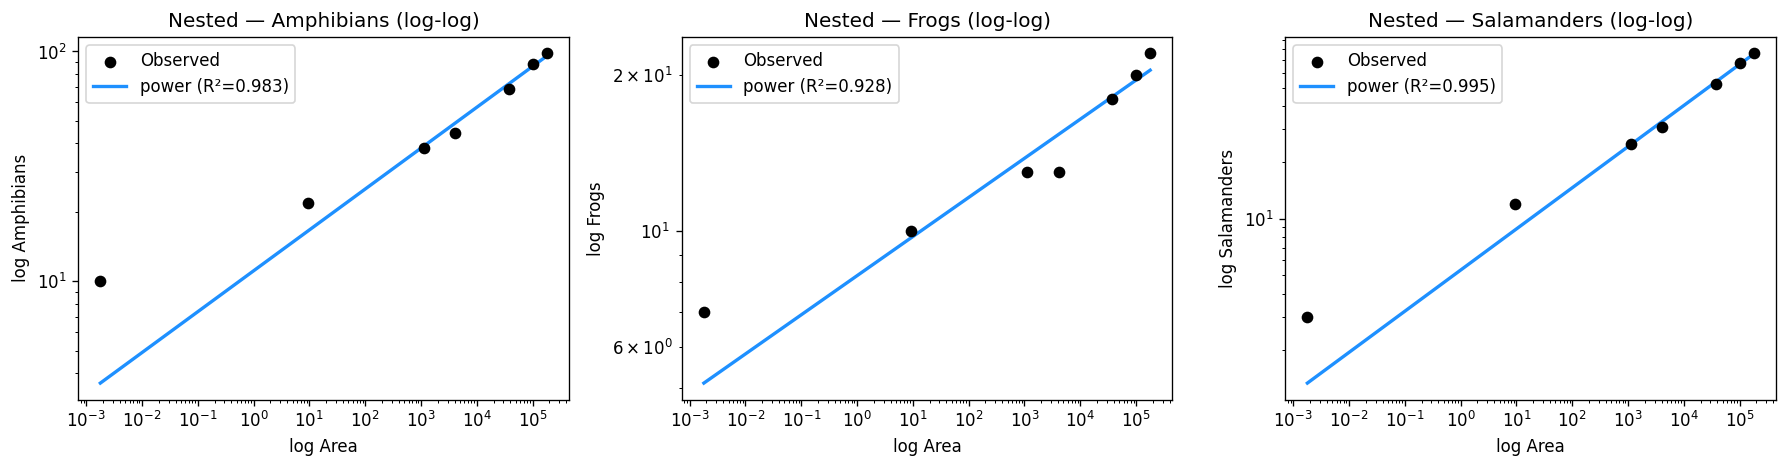

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, label in zip(axes, labels):
    fit = nested_power[label]
    sars.plot_fit(fit, log=True, ax=ax)
    ax.set_title(f"Nested — {label} (log-log)")
    ax.set_xlabel("log Area")
    ax.set_ylabel(f"log {label}")
plt.tight_layout()
plt.show()


### Island Model


In [5]:
island_power = {}

for label, col in zip(labels, groups):
    data = load_sars(island_df, col)
    fit = sars.sar_power(data)
    island_power[label] = fit
    print(f"{label}:  c = {fit.params['c']:.4f},  z = {fit.params['z']:.4f},  R² = {fit.r_squared:.4f}")
    print(f"          AIC = {fit.aic:.2f},  AICc = {fit.aicc:.2f},  BIC = {fit.bic:.2f}")
    print()


Amphibians:  c = 12.8767,  z = 0.1272,  R² = 0.7253
          AIC = 162.12,  AICc = 163.21,  BIC = 165.89

Frogs:  c = 4.9765,  z = 0.1094,  R² = 0.6549
          AIC = 111.65,  AICc = 112.74,  BIC = 115.43

Salamanders:  c = 7.8537,  z = 0.1383,  R² = 0.5812
          AIC = 158.87,  AICc = 159.96,  BIC = 162.65



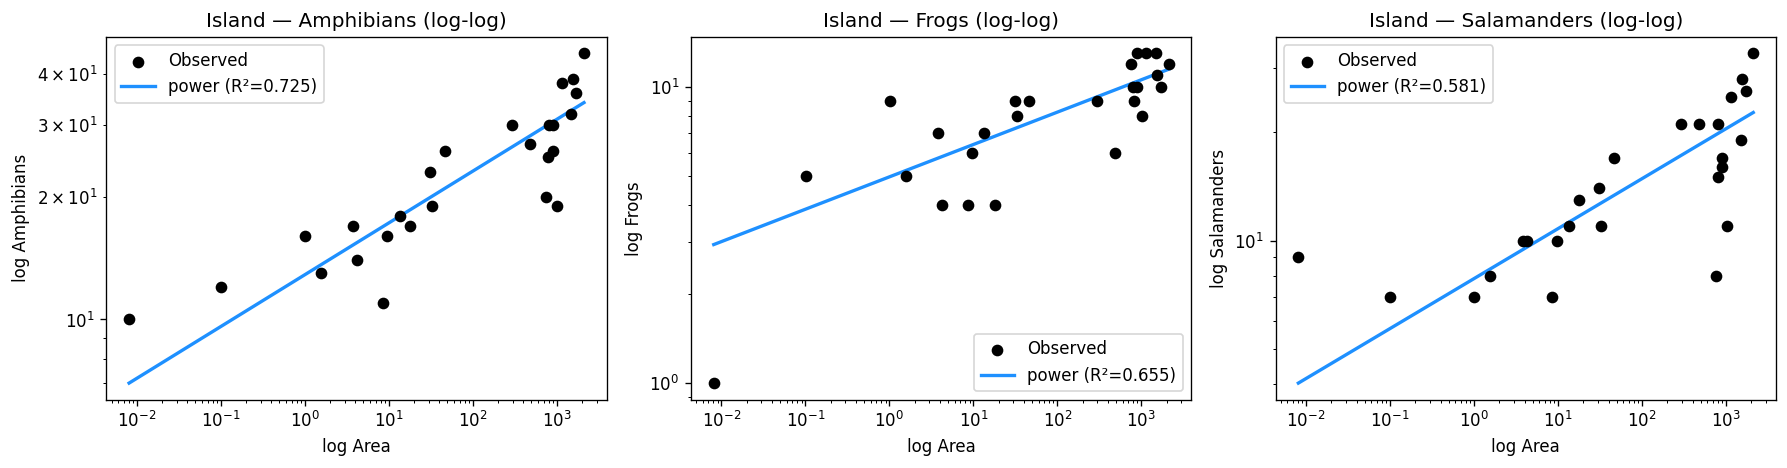

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, label in zip(axes, labels):
    fit = island_power[label]
    sars.plot_fit(fit, log=True, ax=ax)
    ax.set_title(f"Island — {label} (log-log)")
    ax.set_xlabel("log Area")
    ax.set_ylabel(f"log {label}")
plt.tight_layout()
plt.show()


## Cross-Group & Cross-Dataset Power Comparison


In [7]:
rows = []
for label in labels:
    nf = nested_power[label]
    isf = island_power[label]
    rows.append({
        "Group": label,
        "Nested c": round(nf.params['c'], 4),
        "Nested z": round(nf.params['z'], 4),
        "Nested R²": round(nf.r_squared, 4),
        "Island c": round(isf.params['c'], 4),
        "Island z": round(isf.params['z'], 4),
        "Island R²": round(isf.r_squared, 4),
    })
display(pd.DataFrame(rows))


,Group,Nested c,Nested z,Nested R²,Island c,Island z,Island R²
0,Amphibians,11.1076,0.1779,0.9826,12.8767,0.1272,0.7253
1,Frogs,8.2195,0.0753,0.9281,4.9765,0.1094,0.6549
2,Salamanders,5.3315,0.2192,0.9951,7.8537,0.1383,0.5812


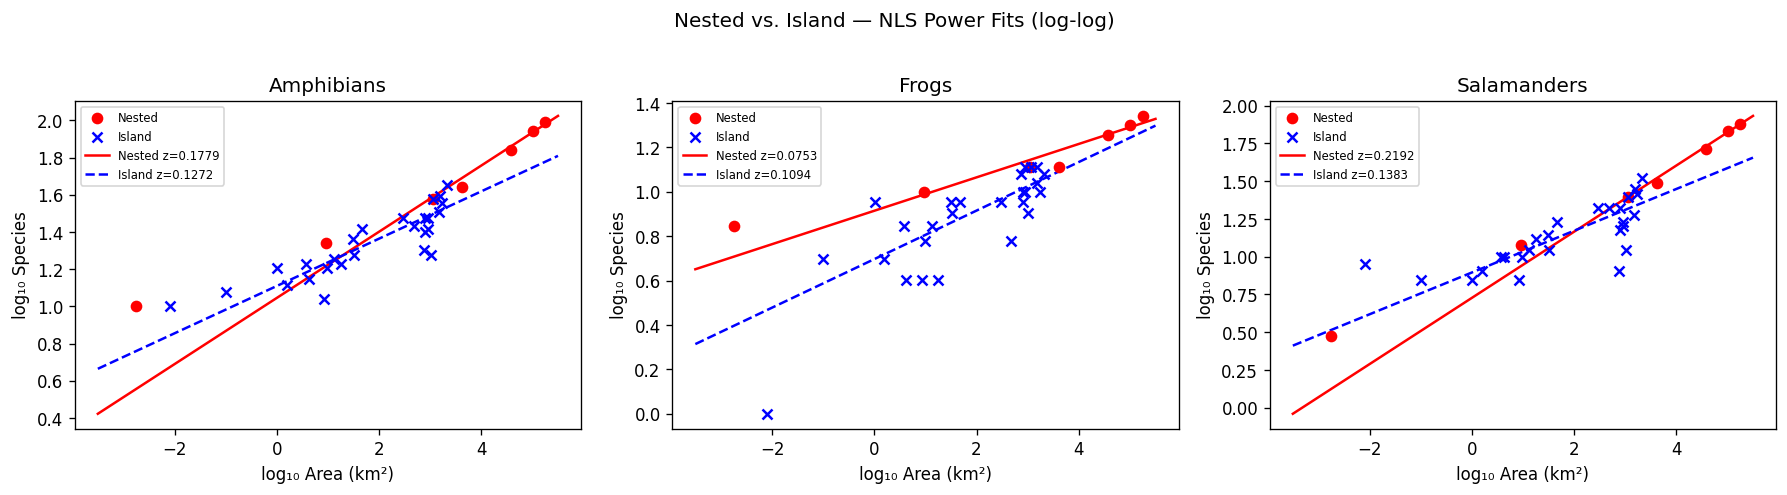

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_n = {"Amphibians": "red", "Frogs": "red", "Salamanders": "red"}
colors_i = {"Amphibians": "blue", "Frogs": "blue", "Salamanders": "blue"}

for ax, label, col in zip(axes, labels, groups):
    nf = nested_power[label]
    isf = island_power[label]

    # nested data + curve
    n_areas = nested_df["Area"].values
    n_species = nested_df[col].values
    ax.scatter(np.log10(n_areas), np.log10(n_species), color="red", marker="o", label="Nested", zorder=5)

    # island data + curve
    i_areas = island_df["Area"].values
    i_species = island_df[col].values
    ax.scatter(np.log10(i_areas), np.log10(i_species), color="blue", marker="x", label="Island", zorder=5)

    # fitted curves in log-log
    x = np.linspace(-3.5, 5.5, 200)
    ax.plot(x, np.log10(nf.params['c']) + nf.params['z'] * x, "r-",
            label=f"Nested z={nf.params['z']:.4f}")
    ax.plot(x, np.log10(isf.params['c']) + isf.params['z'] * x, "b--",
            label=f"Island z={isf.params['z']:.4f}")

    ax.set_title(label)
    ax.set_xlabel("log₁₀ Area (km²)")
    ax.set_ylabel("log₁₀ Species")
    ax.legend(fontsize=7)

plt.suptitle("Nested vs. Island — NLS Power Fits (log-log)", y=1.02)
plt.tight_layout()
plt.show()


## Alternative Model Comparison for Weak Fits

The island power model produces R² < 0.80 for all three groups, with salamanders notably weak. Compare power, linear, logarithmic, and powerR (3-parameter power) models for each island group.


In [9]:
alt_models = [
    ("power",  sars.sar_power),
    ("linear", sars.sar_linear),
    ("loga",   sars.sar_loga),
    ("powerR", sars.sar_powerR),
]

island_alts = {}
for label, col in zip(labels, groups):
    data = load_sars(island_df, col)
    fits = {}
    rows = []
    for name, func in alt_models:
        try:
            fit = func(data)
            fits[name] = fit
            rows.append({"Model": name, "R²": round(fit.r_squared, 4),
                         "AIC": round(fit.aic, 2), "BIC": round(fit.bic, 2)})
        except Exception as e:
            rows.append({"Model": name, "R²": None, "AIC": None, "BIC": None})

    island_alts[label] = fits
    print(f"\n=== Island — {label} ===")
    display(pd.DataFrame(rows))



=== Island — Amphibians ===


,Model,R²,AIC,BIC
0,power,0.7253,162.12,165.89
1,linear,0.7360,161.09,164.86
2,loga,0.6576,167.85,171.62
3,powerR,0.7492,161.76,166.79



=== Island — Frogs ===


,Model,R²,AIC,BIC
0,power,0.6549,111.65,115.43
1,linear,0.5198,120.24,124.01
2,loga,0.6418,112.62,116.40
3,powerR,0.6550,113.64,118.67



=== Island — Salamanders ===


,Model,R²,AIC,BIC
0,power,0.5812,158.87,162.65
1,linear,0.6519,154.06,157.83
2,loga,0.5042,163.26,167.03
3,powerR,0.6564,155.73,160.76


### Island Salamanders — Power vs. Linear Residuals

The linear model outperforms power for island salamanders. Examine residuals side by side.


In [10]:
sal_data = load_sars(island_df, "SalamanderSpecies")
sal_power = island_alts["Salamanders"]["power"]
sal_linear = island_alts["Salamanders"]["linear"]

areas = island_df["Area"].values
obs = island_df["SalamanderSpecies"].values
pow_pred = sal_power.predict(areas)
lin_pred = sal_linear.predict(areas)

resid_df = pd.DataFrame({
    "Locality": island_df["Locality"],
    "Area": areas,
    "Observed": obs,
    "Power Pred": np.round(pow_pred, 1),
    "Power Resid": np.round(obs - pow_pred, 2),
    "Linear Pred": np.round(lin_pred, 1),
    "Linear Resid": np.round(obs - lin_pred, 2),
})
display(resid_df)

print(f"\nPower RMSE:  {np.sqrt(np.mean((obs - pow_pred)**2)):.2f}")
print(f"Linear RMSE: {np.sqrt(np.mean((obs - lin_pred)**2)):.2f}")


,Locality,Area,Observed,Power Pred,Power Resid,Linear Pred,Linear Resid
0,John's Bog (Blue Ridge),0.0081,9,4.0,4.97,10.3,-1.31
1,Henderson Bog,0.1010,7,5.7,1.28,10.3,-3.31
2,UT Arboretum,1.0100,7,7.9,-0.86,10.3,-3.31
3,"Sweet's Farm, Highland Co. VA",1.5700,8,8.4,-0.36,10.3,-2.32
4,Cantonment Area WV,3.7800,10,9.4,0.56,10.3,-0.34
5,Briery Mountain WV,4.2300,10,9.6,0.41,10.3,-0.34
6,Pringle Tract WV,8.5400,7,10.6,-3.57,10.4,-3.38
7,Harper's Ferry NHP WV,9.6500,10,10.7,-0.75,10.4,-0.39
8,New River SP NC,13.4500,11,11.3,-0.25,10.4,0.57
9,Elk Knob SP NC,17.9000,13,11.7,1.29,10.5,2.53



Power RMSE:  4.58
Linear RMSE: 4.17


## Residual Diagnostics


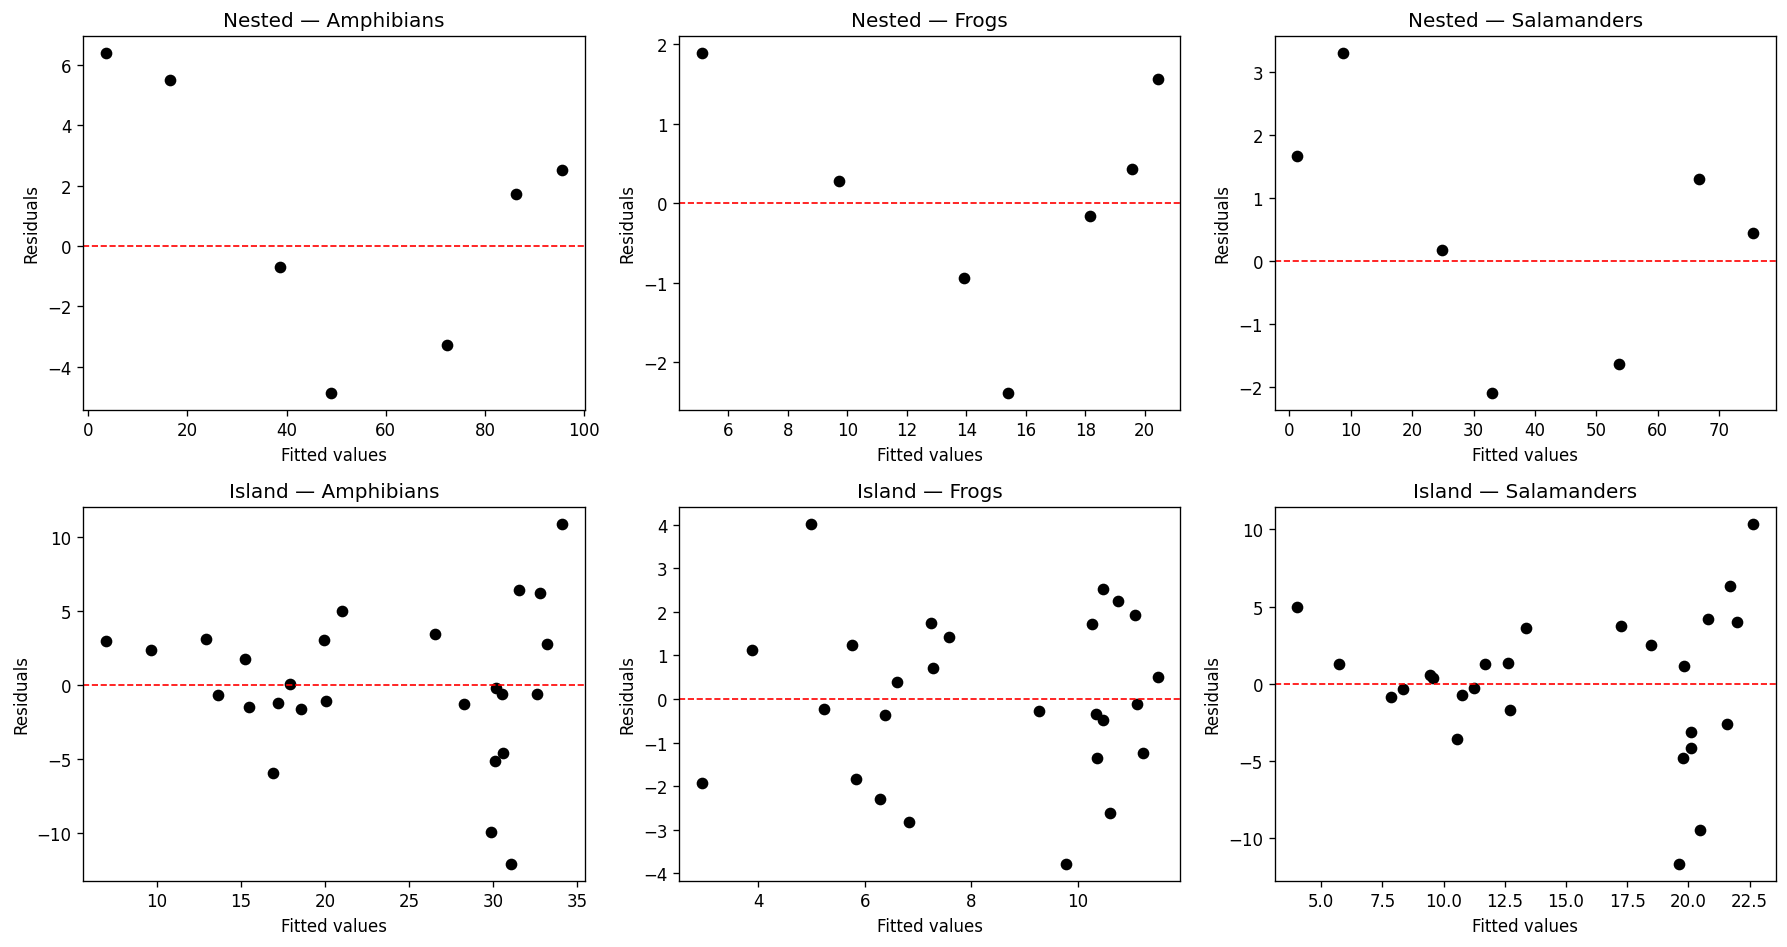

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, (dataset_name, power_dict) in enumerate([("Nested", nested_power), ("Island", island_power)]):
    for j, label in enumerate(labels):
        sars.plot_residuals(power_dict[label], ax=axes[i, j])
        axes[i, j].set_title(f"{dataset_name} — {label}")

plt.tight_layout()
plt.show()


## Multi-Model Comparison

Fit all 20 SAR models supported by `sars` and rank by information criteria.

> **Note on AICc:** With n = 7 (nested) and n = 26 (island), AICc is finite for 2-parameter models in both datasets. For 3-parameter models on the nested data (n = 7, k = 4 including σ), AICc correction is large but still defined since n > k + 1. Results for 3-parameter models on small datasets should be interpreted cautiously.


### Nested — Multi-Model


In [12]:
nested_multi = {}
for label, col in zip(labels, groups):
    data = load_sars(nested_df, col)
    multi = sars.sar_multi(data)
    nested_multi[label] = multi
    print(f"\n=== Nested — {label} (top 5 by BIC) ===")
    display(multi.summary[["model", "R2", "AIC", "AICc", "BIC", "shape"]].head(5))



=== Nested — Amphibians (top 5 by BIC) ===


,model,R2,AIC,AICc,BIC,shape
0,epm2,0.998096,31.982055,51.982055,31.765696,convex
1,power,0.982607,45.468347,53.468347,45.306077,convex
2,epm1,0.997062,35.020279,55.020279,34.803920,convex
3,powerR,0.996501,36.242875,56.242875,36.026515,convex
4,koba,0.907447,57.170380,65.170380,57.008110,convex



=== Nested — Frogs (top 5 by BIC) ===


,model,R2,AIC,AICc,BIC,shape
0,power,0.928067,30.148106,38.148106,29.985837,convex
1,epm2,0.988332,19.415614,39.415614,19.199254,convex
2,powerR,0.986505,20.434249,40.434249,20.217890,convex
3,epm1,0.983185,21.974022,41.974022,21.757663,convex
4,koba,0.823114,36.446468,44.446468,36.284198,convex



=== Nested — Salamanders (top 5 by BIC) ===


,model,R2,AIC,AICc,BIC,shape
0,power,0.995138,34.085615,42.085615,33.923346,convex
1,epm2,0.998615,27.296352,47.296352,27.079993,convex
2,epm1,0.998431,28.167224,48.167224,27.950864,convex
3,powerR,0.997703,30.836526,50.836526,30.620166,convex
4,p1,0.995138,36.085615,56.085615,35.869256,convex


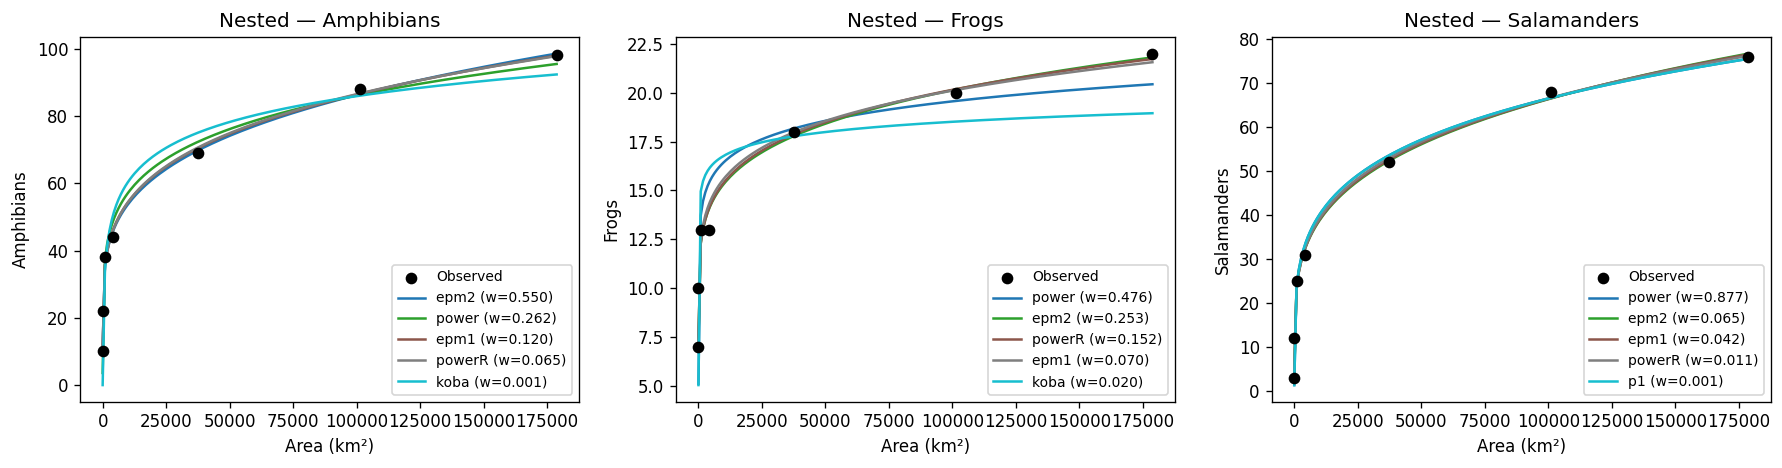

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, label in zip(axes, labels):
    sars.plot_multi(nested_multi[label], top_n=5, ax=ax)
    ax.set_title(f"Nested — {label}")
    ax.set_xlabel("Area (km²)")
    ax.set_ylabel(f"{label}")
plt.tight_layout()
plt.show()


### Island — Multi-Model


In [14]:
island_multi = {}
for label, col in zip(labels, groups):
    data = load_sars(island_df, col)
    multi = sars.sar_multi(data)
    island_multi[label] = multi
    print(f"\n=== Island — {label} (top 5 by BIC) ===")
    display(multi.summary[["model", "R2", "AIC", "AICc", "BIC", "shape"]].head(5))



=== Island — Amphibians (top 5 by BIC) ===


,model,R2,AIC,AICc,BIC,shape
0,linear,0.736029,161.088062,162.178971,164.862351,linear
1,epm2,0.756132,161.028519,162.933281,166.060905,convex
2,power,0.725336,162.120473,163.211382,165.894762,convex
3,powerR,0.749219,161.755317,163.660079,166.787703,convex
4,epm1,0.745837,162.103597,164.008359,167.135983,convex



=== Island — Frogs (top 5 by BIC) ===


,model,R2,AIC,AICc,BIC,shape
0,power,0.654864,111.652134,112.743043,115.426424,convex
1,loga,0.641758,112.621104,113.712013,116.395393,convex
2,koba,0.641501,112.639803,113.730712,116.414093,convex
3,p2,0.667884,112.652323,114.557085,117.684709,convex
4,powerR,0.655022,113.640197,115.544959,118.672583,convex



=== Island — Salamanders (top 5 by BIC) ===


,model,R2,AIC,AICc,BIC,shape
0,linear,0.651926,154.059305,155.150214,157.833595,linear
1,epm2,0.667257,154.888200,156.792962,159.920587,convex
2,gompertz,0.666681,154.933163,156.837925,159.965549,sigmoid
3,powerR,0.656358,155.726165,157.630927,160.758551,convex
4,asymp,0.651917,156.059963,157.964725,161.092349,convex


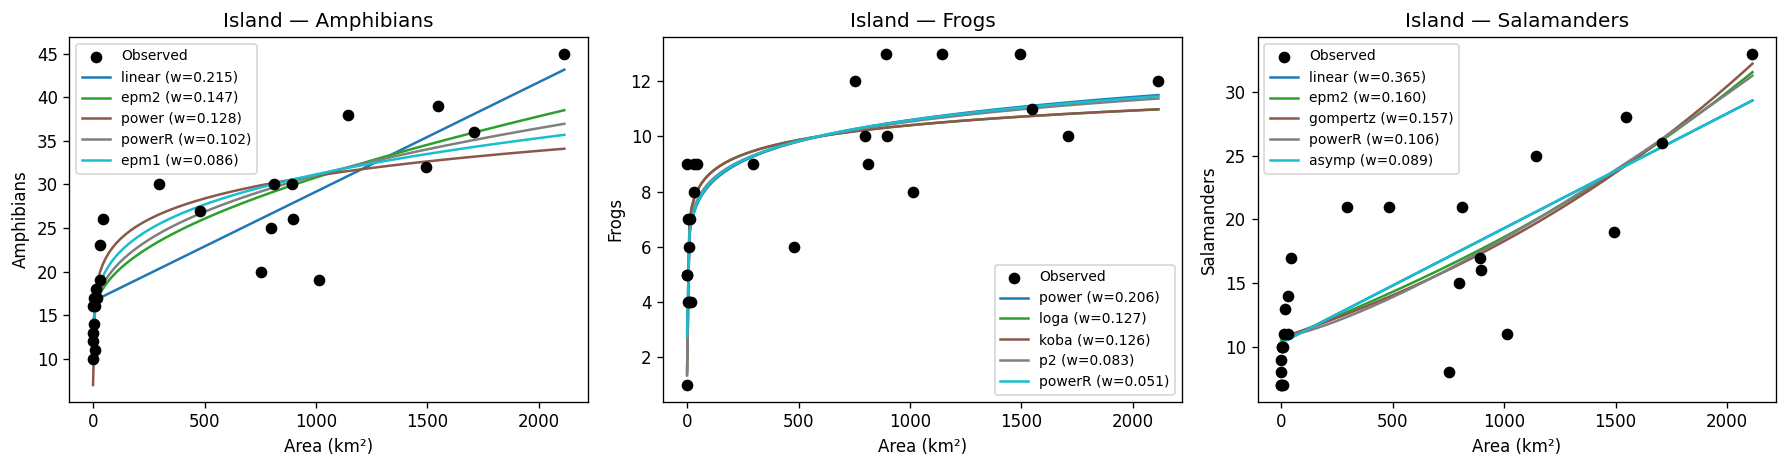

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, label in zip(axes, labels):
    sars.plot_multi(island_multi[label], top_n=5, ax=ax)
    ax.set_title(f"Island — {label}")
    ax.set_xlabel("Area (km²)")
    ax.set_ylabel(f"{label}")
plt.tight_layout()
plt.show()


## Threshold Analysis

`sars.sar_threshold()` tests for breakpoints (small-island effect) by comparing continuous two-slope (ContOne), left-horizontal + right slope (ZslopeOne), and simple linear (no breakpoint) models.


In [16]:
for dataset_name, df in [("Nested", nested_df), ("Island", island_df)]:
    print(f"\n{'=' * 50}")
    print(f"  {dataset_name} — Threshold Analysis")
    print(f"{'=' * 50}")
    for label, col in zip(labels, groups):
        data = load_sars(df, col)
        thresh = sars.sar_threshold(data)
        print(f"\n{label}: best = {thresh.best_model}, breakpoint = {thresh.best_breakpoint}")
        display(thresh.summary)



  Nested — Threshold Analysis

Amphibians: best = Linear, breakpoint = None


,model,breakpoint,AIC,AICc,BIC,R2
0,Linear,NaN,63.442778,71.442778,63.280509,0.773253
1,ZslopeOne,7.015712,56.584148,76.584148,56.367788,0.936036
2,ContOne,9.115712,42.213359,102.213359,41.942910,0.993830



Frogs: best = Linear, breakpoint = None


,model,breakpoint,AIC,AICc,BIC,R2
0,Linear,NaN,36.447290,44.447290,36.285020,0.823093
1,ZslopeOne,7.115712,34.571088,54.571088,34.354728,0.898315
2,ContOne,8.715712,13.604785,73.604785,13.334335,0.996177



Salamanders: best = Linear, breakpoint = None


...

,model,breakpoint,AIC,AICc,BIC,R2
0,ContOne,6.90995,154.387138,157.387138,160.677621,0.825091
1,ZslopeOne,1.80995,164.621757,166.526519,169.654143,0.719989
2,Linear,NaN,167.850605,168.941514,171.624895,0.657614



Frogs: best = Linear, breakpoint = None


,model,breakpoint,AIC,AICc,BIC,R2
0,Linear,NaN,112.621104,113.712013,116.395393,0.641758
1,ContOne,6.20995,113.848939,116.848939,120.139422,0.677989
2,ZslopeOne,1.70995,116.170165,118.074927,121.202551,0.619766



Salamanders: best = ContOne, breakpoint = 6.909950330853168


,model,breakpoint,AIC,AICc,BIC,R2
0,ContOne,6.90995,150.343028,153.343028,156.633510,0.741309
1,ZslopeOne,6.50995,158.638807,160.543569,163.671193,0.615622
2,Linear,NaN,163.258171,164.349080,167.032461,0.504178


## Model Averaging

Model averaging uses Akaike weights derived from AICc to produce information-theoretic weighted predictions. This requires finite AICc for all models. With the island dataset (n = 26), this should be fully available. The nested dataset (n = 7) may have some models with AICc issues depending on parameter count.

We attempt model averaging for each dataset and group, skipping if AICc-based weights are all zero.



  Nested — Model Averaging

Amphibians — Top 5 Akaike weights:
  epm2         0.5502
  power        0.2617
  epm1         0.1204
  powerR       0.0654
  koba         0.0008


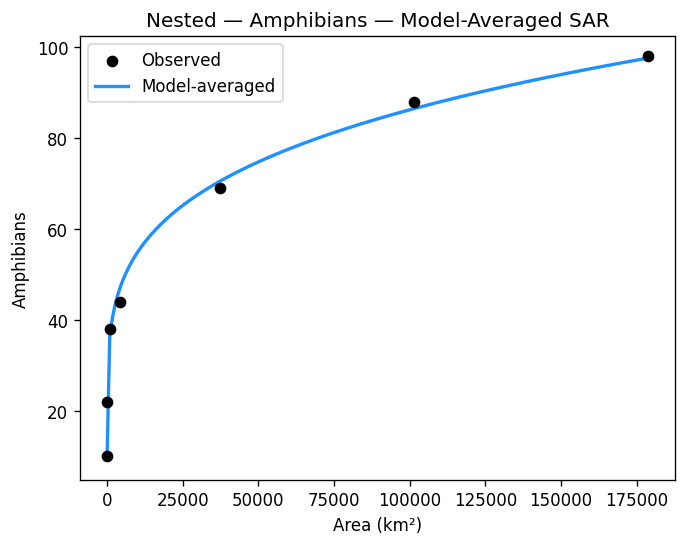


Frogs — Top 5 Akaike weights:
  power        0.4759
  epm2         0.2525
  powerR       0.1517
  epm1         0.0703
  koba         0.0204


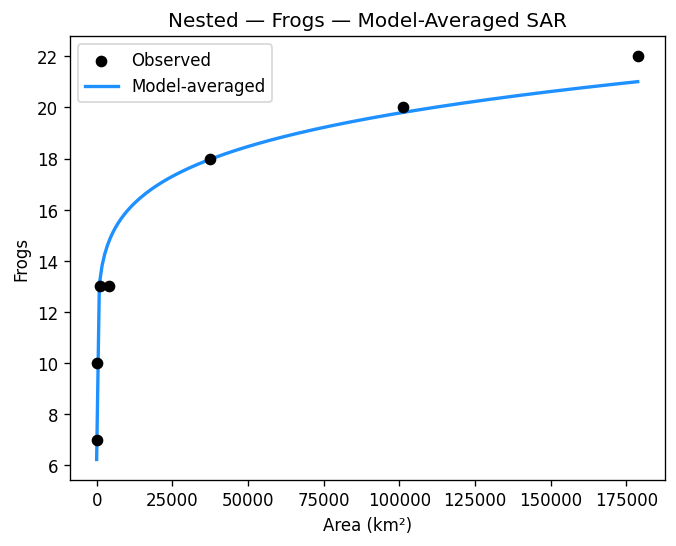


Salamanders — Top 5 Akaike weights:
  power        0.8770
  epm2         0.0648
  epm1         0.0419
  powerR       0.0110
  p1           0.0008


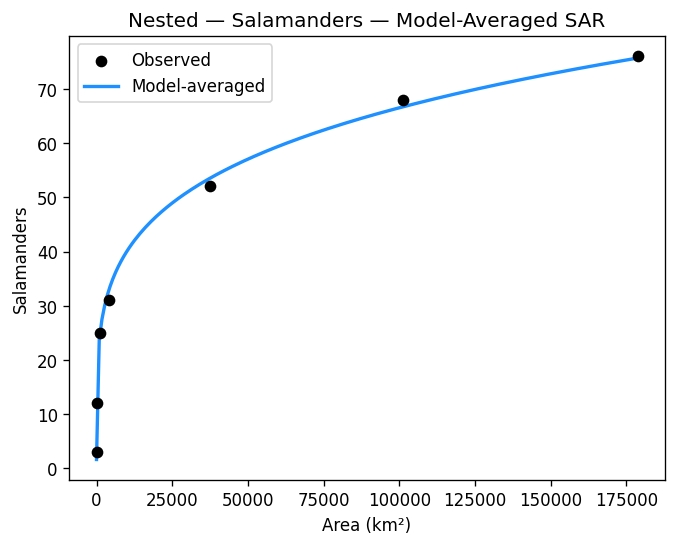


  Island — Model Averaging

Amphibians — Top 5 Akaike weights:
  linear       0.2148
  epm2         0.1473
  power        0.1282
  powerR       0.1024
  epm1         0.0860


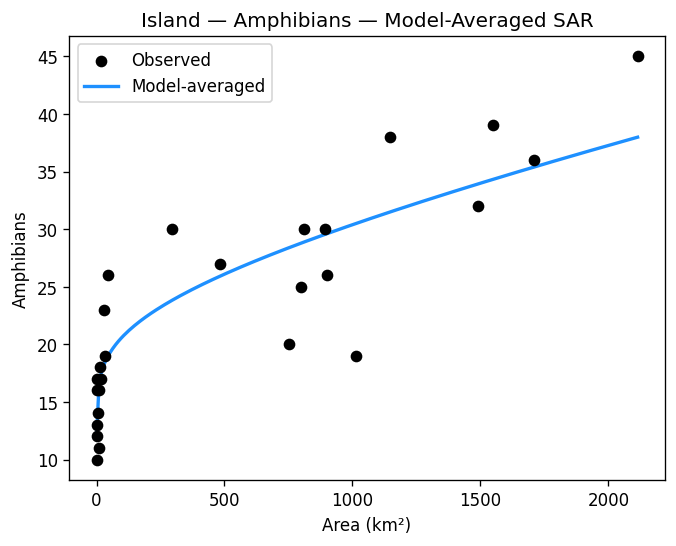


Frogs — Top 5 Akaike weights:
  power        0.2065
  loga         0.1272
  koba         0.1260
  p2           0.0834
  powerR       0.0509


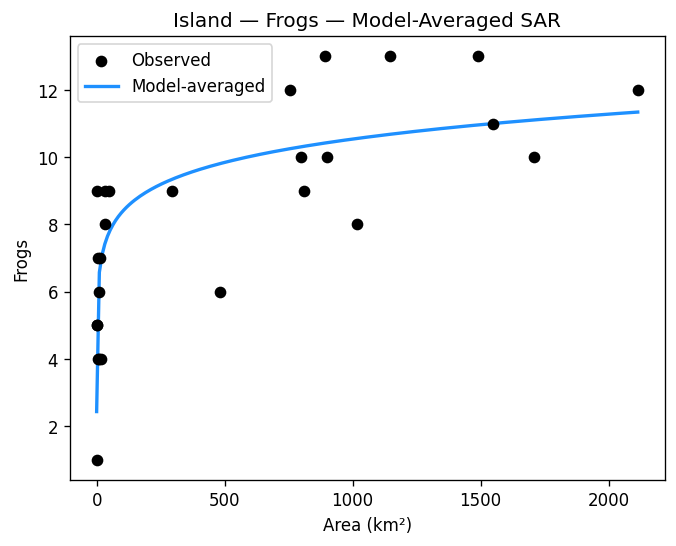


Salamanders — Top 5 Akaike weights:
  linear       0.3649
  epm2         0.1605
  gompertz     0.1569
  powerR       0.1056
  asymp        0.0893


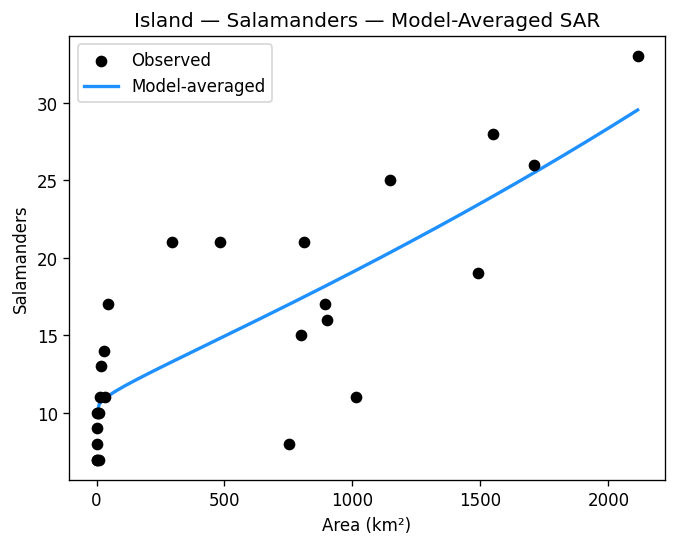

In [17]:
import math

for dataset_name, df in [("Nested", nested_df), ("Island", island_df)]:
    print(f"\n{'=' * 50}")
    print(f"  {dataset_name} — Model Averaging")
    print(f"{'=' * 50}")
    for label, col in zip(labels, groups):
        data = load_sars(df, col)
        try:
            avg = sars.sar_average(data)
            # Check if weights are meaningful
            top_weights = sorted(avg.weights.items(), key=lambda x: -x[1])[:5]
            total_w = sum(w for _, w in top_weights)
            if total_w < 0.01:
                print(f"\n{label}: Akaike weights ≈ 0 (AICc limitation). Skipping.")
                continue
            print(f"\n{label} — Top 5 Akaike weights:")
            for model, w in top_weights:
                print(f"  {model:<12} {w:.4f}")

            sars.plot_average(avg)
            plt.title(f"{dataset_name} — {label} — Model-Averaged SAR")
            plt.xlabel("Area (km²)")
            plt.ylabel(f"{label}")
            plt.show()
        except Exception as e:
            print(f"\n{label}: Model averaging failed — {e}")


## Bootstrap Confidence Intervals

Bootstrap CIs require model averaging to produce meaningful weights. We attempt this for each group where model averaging succeeded.



  Island — Bootstrap CI


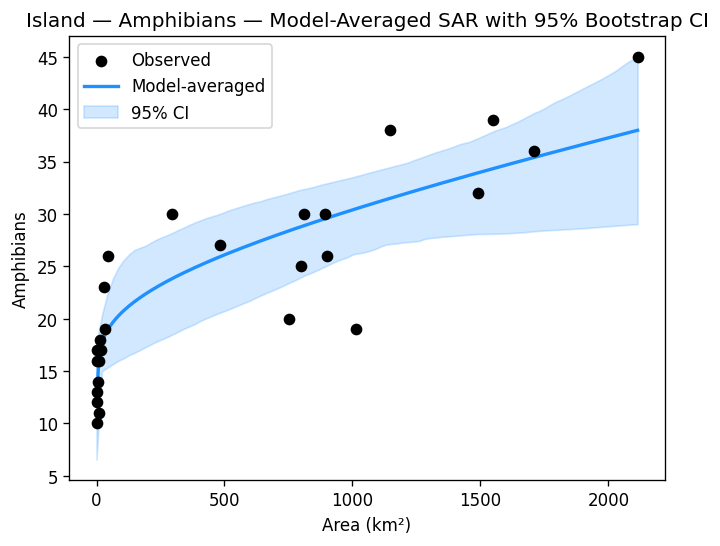


Amphibians: Bootstrap CI computed successfully.


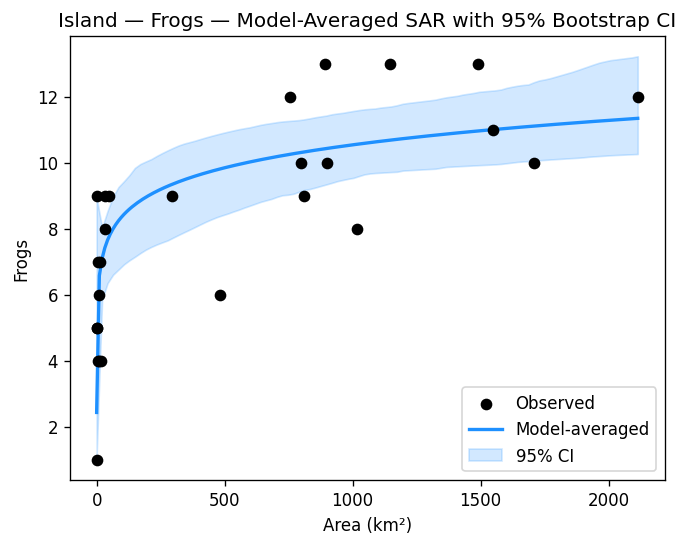


Frogs: Bootstrap CI computed successfully.


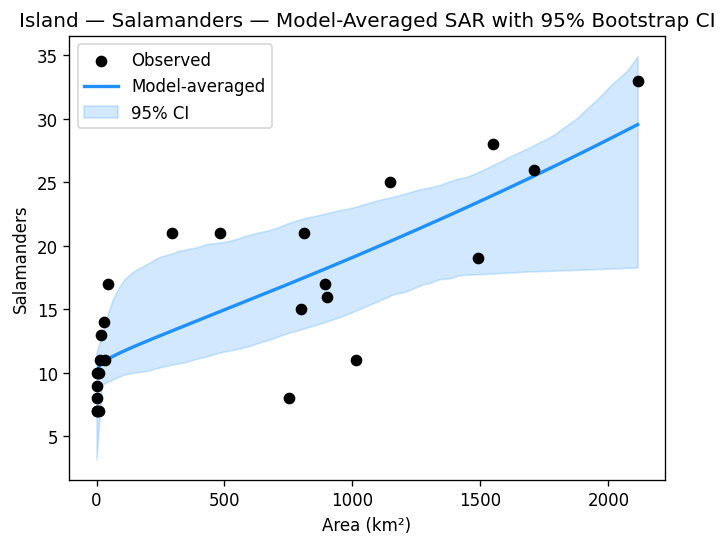


Salamanders: Bootstrap CI computed successfully.


In [18]:
for dataset_name, df in [("Island", island_df)]:
    print(f"\n{'=' * 50}")
    print(f"  {dataset_name} — Bootstrap CI")
    print(f"{'=' * 50}")
    for label, col in zip(labels, groups):
        data = load_sars(df, col)
        try:
            avg = sars.sar_average(data)
            # check weights are non-trivial
            total_w = sum(avg.weights.values())
            if total_w < 0.01:
                print(f"\n{label}: Skipped (zero Akaike weights).")
                continue

            boot = sars.bootstrap_ci(data, n_boot=500, conf=0.95,
                                     rng=np.random.default_rng(42))
            sars.plot_average(avg, boot=boot)
            plt.title(f"{dataset_name} — {label} — Model-Averaged SAR with 95% Bootstrap CI")
            plt.xlabel("Area (km²)")
            plt.ylabel(f"{label}")
            plt.show()
            print(f"\n{label}: Bootstrap CI computed successfully.")
        except Exception as e:
            print(f"\n{label}: Bootstrap CI failed — {e}")


## Predictive Comparison: NLS vs. Original

Compare the NLS power model predictions against the original log-linear OLS predictions at several reference areas. The paper recommends averaging the nested and island models for practical use.


In [19]:
from scipy import stats

# Original (log-linear) parameters
orig = {}
for label, col in zip(labels, groups):
    for dataset_name, df in [("nested", nested_df), ("island", island_df)]:
        log_a = np.log10(df["Area"].values)
        log_s = np.log10(df[col].values)
        result = stats.linregress(log_a, log_s)
        orig[f"{dataset_name}_{label}"] = {"C": 10**result.intercept, "z": result.slope}

test_areas = [1.0, 10.0, 100.0, 1000.0, 10000.0, 100000.0]

print("=== Amphibian Predictions: Nested ===")
print(f"{'Area (km²)':>12}  {'Orig':>8}  {'NLS':>8}  {'Diff':>6}")
print("-" * 40)
for a in test_areas:
    o = orig["nested_Amphibians"]
    n = nested_power["Amphibians"]
    orig_pred = o["C"] * a ** o["z"]
    nls_pred = n.params["c"] * a ** n.params["z"]
    print(f"{a:>12,.1f}  {orig_pred:>8.1f}  {nls_pred:>8.1f}  {nls_pred - orig_pred:>+6.1f}")

print("\n=== Amphibian Predictions: Island ===")
print(f"{'Area (km²)':>12}  {'Orig':>8}  {'NLS':>8}  {'Diff':>6}")
print("-" * 40)
for a in test_areas:
    o = orig["island_Amphibians"]
    n = island_power["Amphibians"]
    orig_pred = o["C"] * a ** o["z"]
    nls_pred = n.params["c"] * a ** n.params["z"]
    print(f"{a:>12,.1f}  {orig_pred:>8.1f}  {nls_pred:>8.1f}  {nls_pred - orig_pred:>+6.1f}")


=== Amphibian Predictions: Nested ===
  Area (km²)      Orig       NLS    Diff
----------------------------------------
         1.0      18.9      11.1    -7.8
        10.0      25.0      16.7    -8.3
       100.0      33.1      25.2    -7.9
     1,000.0      43.9      38.0    -5.9
    10,000.0      58.2      57.2    -1.0
   100,000.0      77.1      86.1    +9.0

=== Amphibian Predictions: Island ===
  Area (km²)      Orig       NLS    Diff
----------------------------------------
         1.0      13.9      12.9    -1.0
        10.0      17.8      17.3    -0.6
       100.0      22.9      23.1    +0.2
     1,000.0      29.3      31.0    +1.7
    10,000.0      37.6      41.5    +3.9
   100,000.0      48.2      55.7    +7.4


In [20]:
# Full comparison table — all groups, both datasets
rows = []
for label, col in zip(labels, groups):
    for dataset_name, df, power_dict in [("Nested", nested_df, nested_power),
                                          ("Island", island_df, island_power)]:
        o = orig[f"{dataset_name.lower()}_{label}"]
        n = power_dict[label]
        rows.append({
            "Dataset": dataset_name,
            "Group": label,
            "Orig C": round(o["C"], 2),
            "NLS c": round(n.params["c"], 4),
            "Orig z": round(o["z"], 4),
            "NLS z": round(n.params["z"], 4),
            "Orig R² (log)": "see analysis.ipynb",
            "NLS R² (arith)": round(n.r_squared, 4),
        })

display(pd.DataFrame(rows))


,Dataset,Group,Orig C,NLS c,Orig z,NLS z,Orig R² (log),NLS R² (arith)
0,Nested,Amphibians,18.87,11.1076,0.1222,0.1779,see analysis.ipynb,0.9826
1,Island,Amphibians,13.92,12.8767,0.1079,0.1272,see analysis.ipynb,0.7253
2,Nested,Frogs,9.34,8.2195,0.0598,0.0753,see analysis.ipynb,0.9281
3,Island,Frogs,4.28,4.9765,0.1338,0.1094,see analysis.ipynb,0.6549
4,Nested,Salamanders,8.36,5.3315,0.1734,0.2192,see analysis.ipynb,0.9951
5,Island,Salamanders,8.95,7.8537,0.1043,0.1383,see analysis.ipynb,0.5812


## References

- Rosenzweig, M.L. (1995). *Species Diversity in Space and Time*. Cambridge University Press.
- Drakare, S., Lennon, J.J. & Hillebrand, H. (2006). The imprint of the geographical, evolutionary and ecological context on species–area relationships. *Ecology Letters* 9:215–227.
- Stout, J.B., Jessee, L.D. & McMeen, J.N. (2025). Nested and island models for determining the species-area relationship of southern Appalachian amphibians. *Journal of North American Herpetology* 2025(1):1–7.
- Tjørve, E. & Tjørve, K.M.C. (2021). Mathematical expressions for the species–area relationship and the assumptions behind the models. In: Matthews, T.J., Triantis, K.A. & Whittaker, R.J. (Eds.), *The Species–Area Relationship: Theory and Application*. Cambridge University Press, pp. 157–184.


---

For full methodological discussion, see [`comparative_analysis.md`](comparative_analysis.md).
